<div style="background-color: #111A33; padding: 28px; border-radius: 10px; text-align: center; color: white; margin-bottom: 25px; box-shadow: 0 4px 8px rgba(0,0,0,0.15);">
    <h1 style="margin: 0; font-size: 34px; font-weight: bold; color: #FFFFFF;">
        DebtStream Digital Collections Analytics (Fintech)
    </h1>
    <p style="margin: 12px 0 0 0; font-size: 19px; color: #F47B20; font-weight: bold;">
        Data Validation, EDA and Funnel Overview
    </p>
    <p style="margin: 8px 0 0 0; font-size: 15px; color: #D9E2EC;">
        Product Analytics | Digital Collections Funnel | Channel Performance | Repayment Journey
    </p>
</div>

<h2 style="color: #0f172a; border-left: 5px solid #F47B20; padding-left: 12px; margin-top: 30px; font-weight: bold;">
Project Context & Objective
</h2>

In this project, I am acting as a **Product Data Analyst at DebtStream**, analysing the digital self-service collections journey across customer accounts uploaded between **June 2022 and May 2023**.

DebtStream is a B2B SaaS platform in the fintech collections space. Its product helps organisations move debt collection journeys into a digital self-service flow, where customers can receive repayment communications, open a secure journey, verify their identity, view their balance, select a payment option, make a payment, or set up a repayment plan.

The objective of this first notebook is to validate the raw data, understand the structure of the customer and event datasets, and explore how customers move through the digital collections funnel before moving into SMS A/B testing and repayment recovery analysis in later notebooks.

<h2 style="color: #0f172a; border-left: 5px solid #F47B20; padding-left: 12px; margin-top: 30px; font-weight: bold;">
The Analytical Pipeline
</h2>

This notebook follows a structured product analytics workflow:

1. **Load and validate the datasets**  
   Confirm that all raw CSVs and SQL-exported summary files load correctly.

2. **Check data quality**  
   Review row counts, missing values, and date ranges.

3. **Explore customer and communication patterns**  
   Understand customer distribution by balance band, debt age, client type, and communication channel.

4. **Analyse the digital collections funnel**  
   Review how customers move from account upload to invite delivery, link open, identity verification, balance view, payment option selection, payment, and repayment plan setup.

5. **Identify major drop-off points**  
   Highlight where the customer journey loses the most users.

6. **Export charts for further use**  
   Save key visual outputs into the project folder for use in the final case study and Power BI validation.

<h2 style="color: #F47B20; border-bottom: 2px solid #D9E2EC; padding-bottom: 8px; margin-top: 40px; font-weight: bold;">
Section 1: Dataset Overview
</h2>


The project uses six core raw data tables:

| Table | Description |
|---|---|
| `debtstream_clients.csv` | B2B client information such as client type, industry, integration type, and client size |
| `debtstream_customers.csv` | Customer account-level data including debt balance, debt age, portfolio type, region, and account status |
| `debtstream_communication_events.csv` | Communication attempts sent to customers through SMS, Email, Letter, or Agent Referral |
| `debtstream_journey_events.csv` | Product journey events such as invite sent, link opened, identity verified, balance viewed, payment made, and repayment plan created |
| `debtstream_payments.csv` | Payment transaction records including payment method, payment amount, payment type, and payment status |
| `debtstream_repayment_plans.csv` | Repayment plan records including plan amount, instalment amount, missed payments, plan status, and affordability completion |

This notebook also uses SQL-exported summary files created during the BigQuery phase, such as the overall funnel, stage drop-off table, funnel by channel, and monthly funnel trend.

<h2 style="color: #F47B20; border-bottom: 2px solid #D9E2EC; padding-bottom: 8px; margin-top: 40px; font-weight: bold;">
Section 2: Library Imports and Project Setup
</h2>

**Import Libraries and Configure Project Paths**

I am importing the Python libraries required for data validation, exploratory analysis, and charting. I am also defining the folder paths for the raw data, SQL-exported summary tables, and chart outputs.

In [2]:
# ============================================================
# Section 2: Library Imports and Project Setup
# ============================================================

# 1. Import core data analysis libraries
import pandas as pd
import numpy as np

# 2. Import visualisation libraries
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# 3. Import operating system library for file paths
import os

# 4. Set pandas display options for easier inspection
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:,.2f}'.format)

# 5. Set simple global chart formatting
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

# 6. Define project folder paths
#    This assumes the notebook is saved inside the /notebooks folder.
BASE_PATH = os.path.abspath(os.path.join(os.getcwd(), '..'))
RAW_DATA_PATH = os.path.join(BASE_PATH, 'data', 'raw')
SUMMARY_TABLES_PATH = os.path.join(BASE_PATH, 'outputs', 'summary_tables')
CHARTS_PATH = os.path.join(BASE_PATH, 'outputs', 'charts')

# 7. Create output folders if they do not already exist
os.makedirs(CHARTS_PATH, exist_ok=True)
os.makedirs(SUMMARY_TABLES_PATH, exist_ok=True)

print("Libraries imported successfully.")
print("Project paths configured.")
print("Base path:", BASE_PATH)

Libraries imported successfully.
Project paths configured.
Base path: C:\Users\Utkarsh\DebtStream_Digital_Collections_Project


<h2 style="color: #F47B20; border-bottom: 2px solid #D9E2EC; padding-bottom: 8px; margin-top: 40px; font-weight: bold;">
Section 3: Load Raw Data and SQL Summary Outputs
</h2>

**Load Raw Data and SQL Summary Outputs**

I am loading the six raw CSV files generated for the DebtStream project, along with the key SQL summary outputs exported from BigQuery.

The raw files will be used for validation and exploratory checks, while the SQL summary outputs will be used to visualise already-validated funnel and channel metrics.

In [3]:
# ============================================================
# Section 3: Load Raw Data and SQL Summary Outputs
# ============================================================

# 1. Load the six raw DebtStream CSV files
clients = pd.read_csv(os.path.join(RAW_DATA_PATH, 'debtstream_clients.csv'))
customers = pd.read_csv(os.path.join(RAW_DATA_PATH, 'debtstream_customers.csv'))
communication_events = pd.read_csv(os.path.join(RAW_DATA_PATH, 'debtstream_communication_events.csv'))
journey_events = pd.read_csv(os.path.join(RAW_DATA_PATH, 'debtstream_journey_events.csv'))
payments = pd.read_csv(os.path.join(RAW_DATA_PATH, 'debtstream_payments.csv'))
repayment_plans = pd.read_csv(os.path.join(RAW_DATA_PATH, 'debtstream_repayment_plans.csv'))

# 2. Load SQL-exported summary tables from the funnel and channel analysis
overall_funnel = pd.read_csv(os.path.join(SUMMARY_TABLES_PATH, 'overall_funnel.csv'))
stage_drop_off = pd.read_csv(os.path.join(SUMMARY_TABLES_PATH, 'stage_drop_off.csv'))
funnel_by_channel = pd.read_csv(os.path.join(SUMMARY_TABLES_PATH, 'funnel_by_channel.csv'))
funnel_by_balance_band = pd.read_csv(os.path.join(SUMMARY_TABLES_PATH, 'funnel_by_balance_band.csv'))
monthly_funnel_trend = pd.read_csv(os.path.join(SUMMARY_TABLES_PATH, 'monthly_funnel_trend.csv'))

# 3. Store raw tables in a dictionary for easier validation later
tables = {
    'clients': clients,
    'customers': customers,
    'communication_events': communication_events,
    'journey_events': journey_events,
    'payments': payments,
    'repayment_plans': repayment_plans
}

print("Raw datasets and SQL summary outputs loaded successfully.")

Raw datasets and SQL summary outputs loaded successfully.


<h2 style="color: #F47B20; border-bottom: 2px solid #D9E2EC; padding-bottom: 8px; margin-top: 40px; font-weight: bold;">
Section 4: Validate Raw Table Structure
</h2>

**Check Raw Table Shapes**

I am checking the number of rows and columns in each raw dataset to confirm that the local Python environment matches the validated BigQuery setup.

This is an important first validation step because any mismatch in row counts would mean the Python analysis is not using the same data that was validated during the SQL phase.

In [4]:
# ============================================================
# Section 4: Validate Raw Table Structure
# ============================================================

# 1. Create an empty list to store table shape summaries
table_shapes = []

# 2. Loop through each raw table and capture rows and columns
for table_name, dataframe in tables.items():
    table_shapes.append({
        'table_name': table_name,
        'rows': dataframe.shape[0],
        'columns': dataframe.shape[1]
    })

# 3. Convert the result into a dataframe
table_shapes_df = pd.DataFrame(table_shapes)

# 4. Display table shape summary
table_shapes_df

,table_name,rows,columns
0,clients,10,9
1,customers,10000,13
2,communication_events,19244,11
3,journey_events,50699,9
4,payments,2362,9
5,repayment_plans,743,11


**Insight & Business Takeaway**

All six raw datasets loaded successfully and match the row counts validated earlier in BigQuery.

This confirms that the Python environment is aligned with the SQL phase and that the notebook can now be used for exploratory analysis, charting, and validation without requiring additional data ingestion work.

**Indication:** The dataset is ready for Python-based EDA and funnel visualisation.

<h2 style="color: #F47B20; border-bottom: 2px solid #D9E2EC; padding-bottom: 8px; margin-top: 40px; font-weight: bold;">
Section 5: Preview Key Tables
</h2>

**Inspect Sample Records**

I am previewing the key tables to understand the structure, column names, and example values before running deeper validation checks.

The customer table gives the account-level view, the communication table shows how customers were contacted, and the journey events table shows how customers moved through the digital collections journey.

In [5]:
# 1. Preview the customer account table
customers.head()

,customer_id,client_id,account_upload_date,portfolio_type,debt_balance,balance_band,debt_age_days,debt_age_band,customer_age_band,region,vulnerability_flag,preferred_contact_channel,account_status
0,DCUST000001,DSC006,2023-04-02,Early Arrears,340.19,Medium,90,31-90,18-24,East Midlands,0,SMS,No Engagement
1,DCUST000002,DSC001,2022-12-10,Recoveries,"5,664.98",Very High,274,181-365,25-34,London,0,SMS,Open
2,DCUST000003,DSC002,2023-01-01,Early Arrears,50.21,Low,31,31-90,55+,South East,0,SMS,Paid
3,DCUST000004,DSC001,2023-03-24,Late Arrears,377.38,Medium,60,31-90,45-54,East Midlands,0,SMS,No Engagement
4,DCUST000005,DSC001,2023-05-01,Late Arrears,135.04,Low,70,31-90,45-54,London,0,SMS,Paid


In [6]:
# 2. Preview the communication events table
communication_events.head()

,communication_id,customer_id,client_id,sent_date,channel,message_type,ab_test_group,message_tone,delivered_flag,opened_or_clicked_flag,days_after_upload
0,COMM0000001,DCUST000001,DSC006,2023-04-04,SMS,Initial Invite,Not Applicable,Supportive,1,0,2
1,COMM0000002,DCUST000002,DSC001,2022-12-11,SMS,Initial Invite,Not Applicable,Informational,1,1,1
2,COMM0000003,DCUST000002,DSC001,2022-12-16,Letter,Reminder 1,Not Applicable,Informational,1,0,6
3,COMM0000004,DCUST000002,DSC001,2022-12-20,Email,Reminder 2,Not Applicable,Supportive,1,0,10
4,COMM0000005,DCUST000003,DSC002,2023-01-02,SMS,Initial Invite,Control,Direct,1,1,1


In [7]:
# 3. Preview the digital journey events table
journey_events.head()

,event_id,customer_id,client_id,event_date,event_name,channel,device_type,session_id,days_since_invite
0,JEVT00000001,DCUST000001,DSC006,2023-04-04,invite_sent,SMS,NaN,SESS0000001,0
1,JEVT00000002,DCUST000001,DSC006,2023-04-04,invite_delivered,SMS,NaN,SESS0000001,0
2,JEVT00000003,DCUST000002,DSC001,2022-12-11,invite_sent,SMS,NaN,SESS0000002,0
3,JEVT00000004,DCUST000002,DSC001,2022-12-11,invite_delivered,SMS,NaN,SESS0000002,0
4,JEVT00000005,DCUST000002,DSC001,2022-12-11,link_opened,SMS,Mobile,SESS0000003,0


<h2 style="color: #F47B20; border-bottom: 2px solid #D9E2EC; padding-bottom: 8px; margin-top: 40px; font-weight: bold;">
Section 6: Missing Value Checks
</h2>

**Review Missing Values in Core Tables**

I am checking missing values in the main raw datasets to understand whether any important fields require cleaning or careful interpretation.

For this project, not every missing value is automatically a data quality issue. For example, some journey events may not have a device type because invite delivery events do not always happen inside a browser or app session.

In [8]:
# ============================================================
# Section 6: Missing Value Checks
# ============================================================

# 1. Create a function to summarise missing values
def missing_value_summary(dataframe, table_name):
    missing_summary = pd.DataFrame({
        'table_name': table_name,
        'column_name': dataframe.columns,
        'missing_values': dataframe.isnull().sum().values,
        'missing_percent': (dataframe.isnull().sum().values / len(dataframe) * 100)
    })
    
    # 2. Keep only columns where missing values exist
    missing_summary = missing_summary[missing_summary['missing_values'] > 0]
    
    # 3. Sort by highest missing percentage
    missing_summary = missing_summary.sort_values(by='missing_percent', ascending=False)
    
    return missing_summary


# 4. Apply the function to all raw tables
missing_summaries = []

for table_name, dataframe in tables.items():
    missing_summaries.append(missing_value_summary(dataframe, table_name))

# 5. Combine missing value summaries
missing_values_df = pd.concat(missing_summaries, ignore_index=True)

# 6. Display missing value summary
missing_values_df

,table_name,column_name,missing_values,missing_percent
0,customers,customer_age_band,150,1.50
1,customers,region,70,0.70
2,customers,preferred_contact_channel,70,0.70
3,journey_events,device_type,37506,73.98
4,payments,payment_method,10,0.42


**Insight & Business Takeaway**

The missing value check shows that most core fields are complete, with only small missing percentages in customer-level attributes such as `customer_age_band`, `region`, and `preferred_contact_channel`.

The largest missing value percentage appears in `journey_events.device_type`, where around 74% of rows are missing. This is expected because not every journey event is a browser or app-based customer action. System-driven events such as invite sent or invite delivered may not have a device type attached.

Similarly, the small number of missing `payment_method` records is not concerning because those records are likely linked to failed payment attempts where no completed payment method was captured.

**Indication:** No immediate data cleaning is required at this stage. Missing values should be interpreted based on business context, and `device_type` should only be used later if the analysis specifically focuses on digital device behaviour.

<h2 style="color: #F47B20; border-bottom: 2px solid #D9E2EC; padding-bottom: 8px; margin-top: 40px; font-weight: bold;">
Section 7: Date Range Validation
</h2>

**Validate Project Timeline**

I am checking the minimum and maximum dates across the main date fields to confirm that the dataset reflects the expected project period.

Customer accounts and communications should sit between **June 2022 and May 2023**, while journey events and payments may extend slightly beyond May 2023 because customers can complete actions after their initial account upload or invite date.

In [9]:
# ============================================================
# Section 7: Date Range Validation
# ============================================================

# 1. Convert key date columns to datetime format
customers['account_upload_date'] = pd.to_datetime(customers['account_upload_date'])
communication_events['sent_date'] = pd.to_datetime(communication_events['sent_date'])
journey_events['event_date'] = pd.to_datetime(journey_events['event_date'])
payments['payment_date'] = pd.to_datetime(payments['payment_date'])
repayment_plans['plan_created_date'] = pd.to_datetime(repayment_plans['plan_created_date'])

print("Date columns converted successfully.")

Date columns converted successfully.


In [10]:
# 2. Create date range summary for core project tables
date_range_summary = pd.DataFrame({
    'table_name': [
        'customers',
        'communication_events',
        'journey_events',
        'payments',
        'repayment_plans'
    ],
    'date_field': [
        'account_upload_date',
        'sent_date',
        'event_date',
        'payment_date',
        'plan_created_date'
    ],
    'min_date': [
        customers['account_upload_date'].min(),
        communication_events['sent_date'].min(),
        journey_events['event_date'].min(),
        payments['payment_date'].min(),
        repayment_plans['plan_created_date'].min()
    ],
    'max_date': [
        customers['account_upload_date'].max(),
        communication_events['sent_date'].max(),
        journey_events['event_date'].max(),
        payments['payment_date'].max(),
        repayment_plans['plan_created_date'].max()
    ]
})

date_range_summary

,table_name,date_field,min_date,max_date
0,customers,account_upload_date,2022-06-01,2023-05-31
1,communication_events,sent_date,2022-06-01,2023-05-31
2,journey_events,event_date,2022-06-01,2023-06-03
3,payments,payment_date,2022-06-02,2023-07-14
4,repayment_plans,plan_created_date,2022-06-04,2023-05-31


**Insight & Business Takeaway**

The date ranges align with the expected project period. Customer account uploads and communications sit within the June 2022 to May 2023 window, while journey events and payments extend slightly beyond May 2023.

This is expected because a customer uploaded or contacted near the end of May may still open the journey, make a payment, or complete a repayment action in June or July.

**Indication:** The dataset timeline is realistic and does not require date filtering at this stage.

<h2 style="color: #F47B20; border-bottom: 2px solid #D9E2EC; padding-bottom: 8px; margin-top: 40px; font-weight: bold;">
Section 8: Customer and Account Distribution
</h2>

**Explore Customer Distribution by Core Business Segments**

I am now exploring how customer accounts are distributed by balance band, debt age band, client type, and portfolio type.

This helps identify the shape of the customer base before interpreting funnel performance or repayment outcomes.

In [11]:
# ============================================================
# Section 8: Customer and Account Distribution
# ============================================================

# 1. Create customer distribution by balance band
balance_band_distribution = (
    customers
    .groupby('balance_band')
    .agg(customers=('customer_id', 'nunique'))
    .reset_index()
)

# 2. Add customer share percentage
balance_band_distribution['customer_share_percent'] = (
    balance_band_distribution['customers'] / balance_band_distribution['customers'].sum() * 100
)

# 3. Apply business order
balance_order = ['Low', 'Medium', 'High', 'Very High']
balance_band_distribution['balance_band'] = pd.Categorical(
    balance_band_distribution['balance_band'],
    categories=balance_order,
    ordered=True
)

balance_band_distribution = balance_band_distribution.sort_values('balance_band')

balance_band_distribution

,balance_band,customers,customer_share_percent
1,Low,3508,35.08
2,Medium,4065,40.65
0,High,1853,18.53
3,Very High,574,5.74


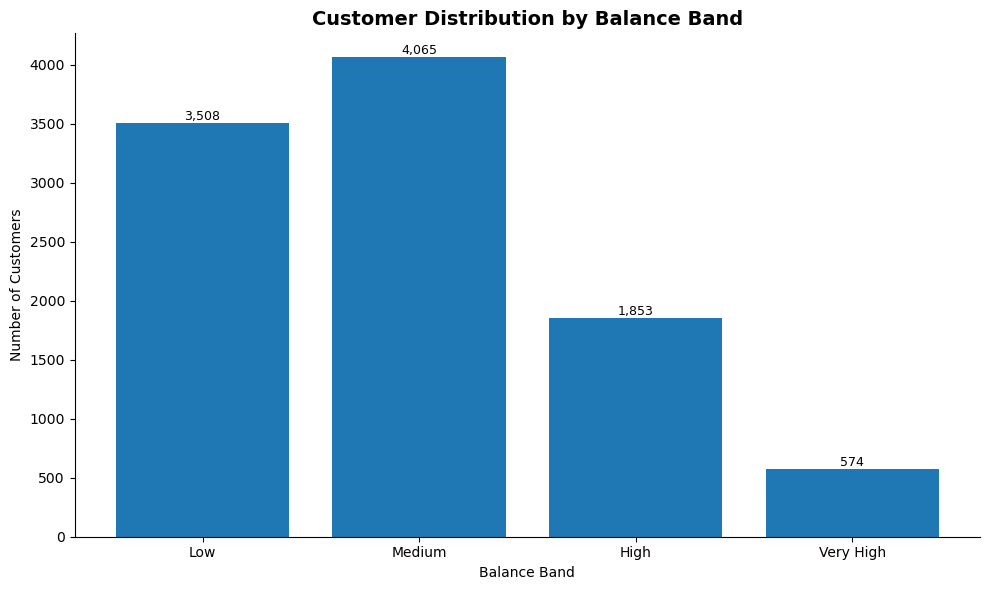

In [12]:
# 4. Plot customer distribution by balance band
fig, ax = plt.subplots()

ax.bar(
    balance_band_distribution['balance_band'].astype(str),
    balance_band_distribution['customers']
)

ax.set_title('Customer Distribution by Balance Band', fontsize=14, fontweight='bold')
ax.set_xlabel('Balance Band')
ax.set_ylabel('Number of Customers')

# 5. Add value labels
for index, value in enumerate(balance_band_distribution['customers']):
    ax.text(index, value, f'{value:,.0f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(CHARTS_PATH, 'customer_distribution_by_balance_band.png'), dpi=300, bbox_inches='tight')
plt.show()

**Insight & Business Takeaway**

Most customer accounts sit in the **Low** and **Medium** balance bands, while **Very High** balance accounts represent a smaller share of the total customer base.

This is important because customer volume and commercial exposure are not the same. Low and Medium balance customers may drive more engagement volume, while High and Very High balance customers can still represent significant recovery risk because of larger outstanding balances.

**Indication:** Later recovery analysis should compare both customer count and outstanding balance, not just account volume.

<h2 style="color: #F47B20; border-bottom: 2px solid #D9E2EC; padding-bottom: 8px; margin-top: 40px; font-weight: bold;">
Section 9: Debt Age Distribution
</h2>

**Explore Customer Distribution by Debt Age Band**

I am analysing how customer accounts are distributed by debt age band. This helps understand whether the portfolio is mostly made up of newer debt accounts, older accounts, or a mix of both.

Debt age is important because newer debts are usually more responsive to digital repayment journeys, while older debts often show weaker engagement and recovery behaviour.

In [13]:
# ============================================================
# Section 9: Debt Age Distribution
# ============================================================

# 1. Create customer distribution by debt age band
debt_age_distribution = (
    customers
    .groupby('debt_age_band')
    .agg(customers=('customer_id', 'nunique'))
    .reset_index()
)

# 2. Add customer share percentage
debt_age_distribution['customer_share_percent'] = (
    debt_age_distribution['customers'] / debt_age_distribution['customers'].sum() * 100
)

# 3. Apply business order
debt_age_order = ['0-30', '31-90', '91-180', '181-365', '365+']
debt_age_distribution['debt_age_band'] = pd.Categorical(
    debt_age_distribution['debt_age_band'],
    categories=debt_age_order,
    ordered=True
)

debt_age_distribution = debt_age_distribution.sort_values('debt_age_band')

debt_age_distribution

,debt_age_band,customers,customer_share_percent
0,0-30,1539,15.39
2,31-90,2123,21.23
4,91-180,2842,28.42
1,181-365,2224,22.24
3,365+,1272,12.72


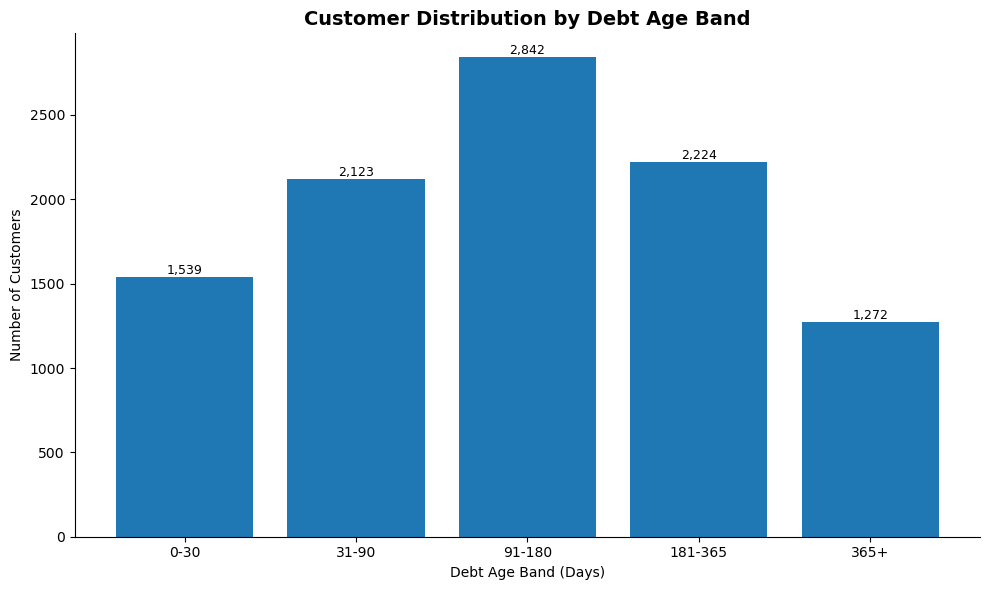

In [15]:
# 4. Plot customer distribution by debt age band
fig, ax = plt.subplots()

ax.bar(
    debt_age_distribution['debt_age_band'].astype(str),
    debt_age_distribution['customers']
)

ax.set_title('Customer Distribution by Debt Age Band', fontsize=14, fontweight='bold')
ax.set_xlabel('Debt Age Band (Days)')
ax.set_ylabel('Number of Customers')

# 5. Add value labels
for index, value in enumerate(debt_age_distribution['customers']):
    ax.text(index, value, f'{value:,.0f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(CHARTS_PATH, 'customer_distribution_by_debt_age_band.png'), dpi=300, bbox_inches='tight')
plt.show()

**Insight & Business Takeaway**

The customer base is spread across multiple debt age bands, with meaningful volume in both newer and older debt groups.

This matters because debt age can strongly influence digital collections performance. Newer debts are typically more responsive to repayment prompts, while older debts often require more supportive journeys, affordability checks, or alternative intervention strategies.

**Indication:** Debt age should be treated as a key segmentation variable in later repayment and recovery analysis.

<h2 style="color: #F47B20; border-bottom: 2px solid #D9E2EC; padding-bottom: 8px; margin-top: 40px; font-weight: bold;">
Section 10: Client Type Distribution
</h2>

**Explore Customer Distribution by Client Type**

I am joining the customer table with the client table to understand how accounts are distributed across DebtStream's B2B client types.

This is important because DebtStream is a B2B SaaS platform, so performance should not only be analysed at customer level, but also across client portfolio types such as lenders, utilities, telecoms, debt purchasers, and collections agencies.

In [16]:
# ============================================================
# Section 10: Client Type Distribution
# ============================================================

# 1. Join customers with clients to bring client-level fields into the customer dataset
customers_with_clients = customers.merge(
    clients,
    on='client_id',
    how='left'
)

# 2. Check the shape after joining
print("Customers table shape:", customers.shape)
print("Customers with clients shape:", customers_with_clients.shape)

Customers table shape: (10000, 13)
Customers with clients shape: (10000, 21)


In [17]:
# 3. Create customer distribution by client type
client_type_distribution = (
    customers_with_clients
    .groupby('client_type')
    .agg(customers=('customer_id', 'nunique'))
    .reset_index()
    .sort_values('customers', ascending=False)
)

# 4. Add customer share percentage
client_type_distribution['customer_share_percent'] = (
    client_type_distribution['customers'] / client_type_distribution['customers'].sum() * 100
)

client_type_distribution

,client_type,customers,customer_share_percent
5,Utility Provider,3494,34.94
0,Consumer Lender,2426,24.26
1,Debt Collection Agency,2003,20.03
2,Debt Purchaser,933,9.33
4,Telecoms,781,7.81
3,Legal Collections,363,3.63


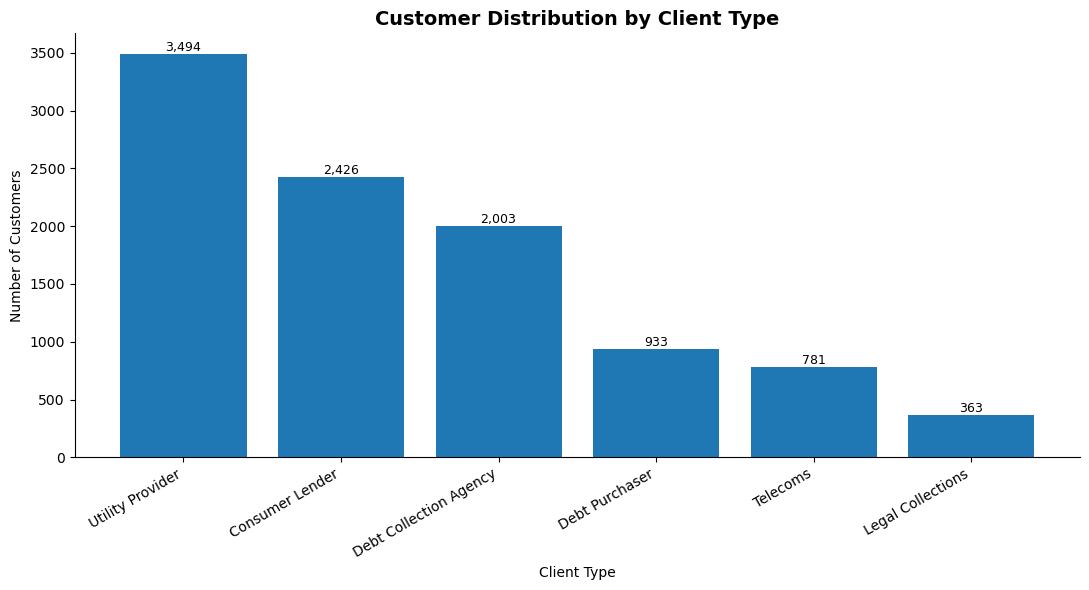

In [18]:
# 5. Plot customer distribution by client type
fig, ax = plt.subplots(figsize=(11, 6))

ax.bar(
    client_type_distribution['client_type'],
    client_type_distribution['customers']
)

ax.set_title('Customer Distribution by Client Type', fontsize=14, fontweight='bold')
ax.set_xlabel('Client Type')
ax.set_ylabel('Number of Customers')

# 6. Rotate labels for readability
plt.xticks(rotation=30, ha='right')

# 7. Add value labels
for index, value in enumerate(client_type_distribution['customers']):
    ax.text(index, value, f'{value:,.0f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(CHARTS_PATH, 'customer_distribution_by_client_type.png'), dpi=300, bbox_inches='tight')
plt.show()

**Insight & Business Takeaway**

The customer base is not evenly distributed across client types. Some portfolios contribute significantly more customer accounts than others, which means overall funnel performance can be influenced by the largest client categories.

For a B2B SaaS collections platform, this matters because different client types may have different customer behaviours, debt profiles, repayment urgency, and recovery outcomes.

**Indication:** Later analysis should compare repayment and recovery performance by client type rather than only looking at the overall average.

<h2 style="color: #F47B20; border-bottom: 2px solid #D9E2EC; padding-bottom: 8px; margin-top: 40px; font-weight: bold;">
Section 11: Portfolio Type Distribution
</h2>

**Explore Customer Distribution by Portfolio Type**

I am analysing customer distribution by portfolio type to understand the mix of debt accounts being processed through DebtStream's digital collections journey.

Portfolio type provides additional business context because early arrears, late arrears, collections, and debt purchase portfolios can behave very differently.

In [19]:
# ============================================================
# Section 11: Portfolio Type Distribution
# ============================================================

# 1. Create customer distribution by portfolio type
portfolio_type_distribution = (
    customers
    .groupby('portfolio_type')
    .agg(customers=('customer_id', 'nunique'))
    .reset_index()
    .sort_values('customers', ascending=False)
)

# 2. Add customer share percentage
portfolio_type_distribution['customer_share_percent'] = (
    portfolio_type_distribution['customers'] / portfolio_type_distribution['customers'].sum() * 100
)

portfolio_type_distribution

,portfolio_type,customers,customer_share_percent
1,Late Arrears,2870,28.70
0,Early Arrears,2789,27.89
4,Recoveries,2275,22.75
3,Purchased Debt,1198,11.98
2,Legal Collections,868,8.68


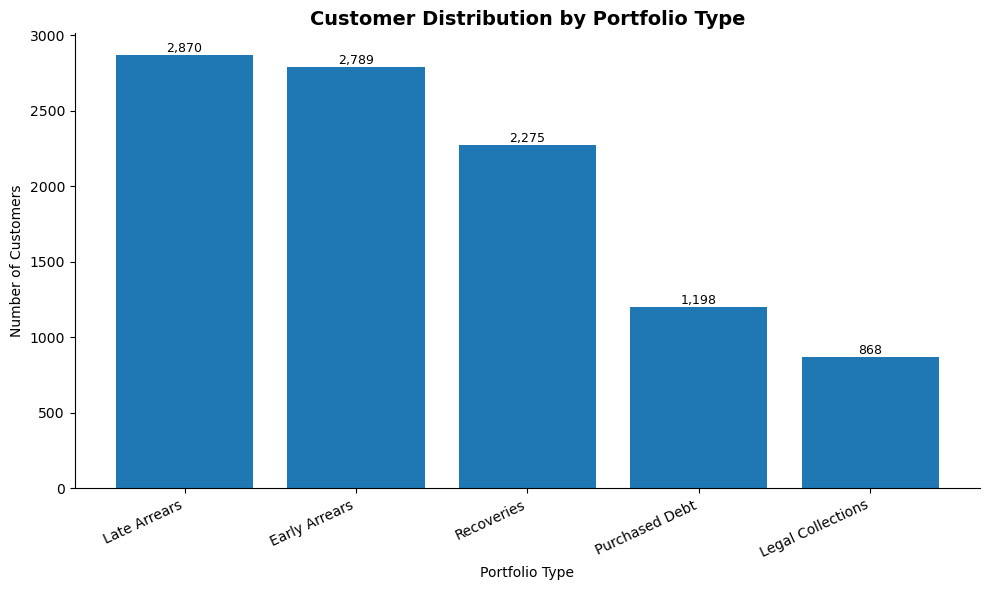

In [20]:
# 3. Plot customer distribution by portfolio type
fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(
    portfolio_type_distribution['portfolio_type'],
    portfolio_type_distribution['customers']
)

ax.set_title('Customer Distribution by Portfolio Type', fontsize=14, fontweight='bold')
ax.set_xlabel('Portfolio Type')
ax.set_ylabel('Number of Customers')

plt.xticks(rotation=25, ha='right')

# 4. Add value labels
for index, value in enumerate(portfolio_type_distribution['customers']):
    ax.text(index, value, f'{value:,.0f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(CHARTS_PATH, 'customer_distribution_by_portfolio_type.png'), dpi=300, bbox_inches='tight')
plt.show()

**Insight & Business Takeaway**

Portfolio type gives additional context to the customer base beyond balance and debt age. A portfolio with more early arrears accounts may naturally show stronger engagement than a portfolio made up of older collections or debt purchase accounts.

**Indication:** Portfolio type should be used as a secondary lens when interpreting funnel, repayment, and recovery outcomes.

<h2 style="color: #F47B20; border-bottom: 2px solid #D9E2EC; padding-bottom: 8px; margin-top: 40px; font-weight: bold;">
Section 12: Communication Channel Exploration
</h2>

**Explore Communication Channel Distribution**

I am analysing the communication events table to understand how customers were contacted across SMS, Email, Letter, and Agent Referral channels.

This is important because communication channel is one of the main levers in a digital collections journey. Channel mix can affect link open rates, identity verification, payment behaviour, and repayment plan setup.

In [21]:
# ============================================================
# Section 12: Communication Channel Exploration
# ============================================================

# 1. Create communication count by channel
channel_distribution = (
    communication_events
    .groupby('channel')
    .agg(communication_count=('communication_id', 'nunique'))
    .reset_index()
    .sort_values('communication_count', ascending=False)
)

# 2. Add communication share percentage
channel_distribution['communication_share_percent'] = (
    channel_distribution['communication_count'] / channel_distribution['communication_count'].sum() * 100
)

channel_distribution

,channel,communication_count,communication_share_percent
3,SMS,10998,57.15
1,Email,5609,29.15
2,Letter,1965,10.21
0,Agent Referral,672,3.49


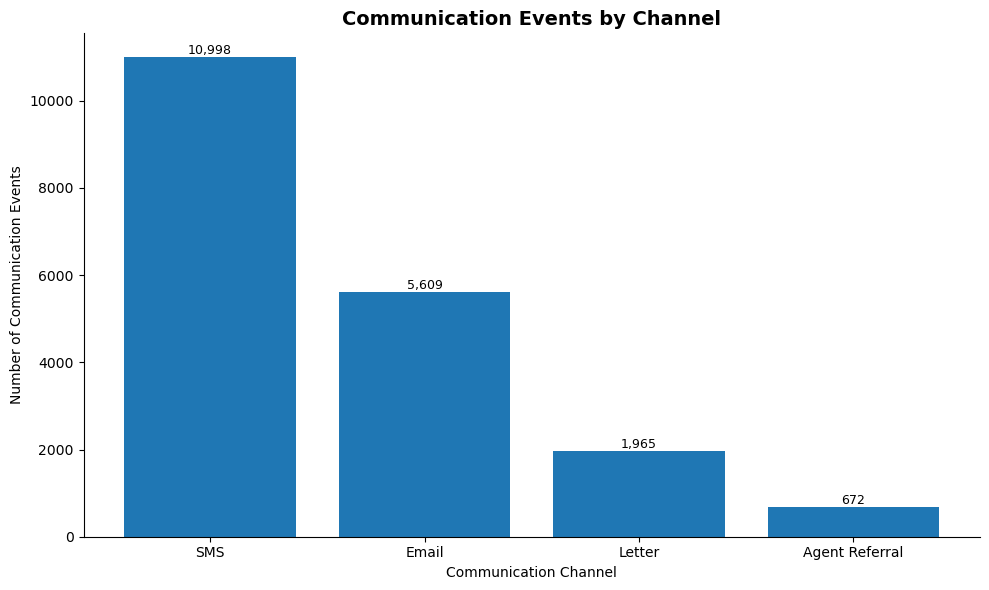

In [22]:
# 3. Plot communication distribution by channel
fig, ax = plt.subplots()

ax.bar(
    channel_distribution['channel'],
    channel_distribution['communication_count']
)

ax.set_title('Communication Events by Channel', fontsize=14, fontweight='bold')
ax.set_xlabel('Communication Channel')
ax.set_ylabel('Number of Communication Events')

# 4. Add value labels
for index, value in enumerate(channel_distribution['communication_count']):
    ax.text(index, value, f'{value:,.0f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(CHARTS_PATH, 'communication_events_by_channel.png'), dpi=300, bbox_inches='tight')
plt.show()

In [23]:
# 5. Create delivery and open/click performance by channel
channel_engagement = (
    communication_events
    .groupby('channel')
    .agg(
        communication_count=('communication_id', 'nunique'),
        delivered_count=('delivered_flag', 'sum'),
        opened_or_clicked_count=('opened_or_clicked_flag', 'sum')
    )
    .reset_index()
)

# 6. Calculate rates
channel_engagement['delivery_rate'] = (
    channel_engagement['delivered_count'] / channel_engagement['communication_count'] * 100
)

channel_engagement['open_or_click_rate'] = (
    channel_engagement['opened_or_clicked_count'] / channel_engagement['delivered_count'] * 100
)

# 7. Sort by communication count
channel_engagement = channel_engagement.sort_values('communication_count', ascending=False)

channel_engagement

,channel,communication_count,delivered_count,opened_or_clicked_count,delivery_rate,open_or_click_rate
3,SMS,10998,10482,2861,95.31,27.29
1,Email,5609,5072,967,90.43,19.07
2,Letter,1965,1922,145,97.81,7.54
0,Agent Referral,672,672,315,100.00,46.88


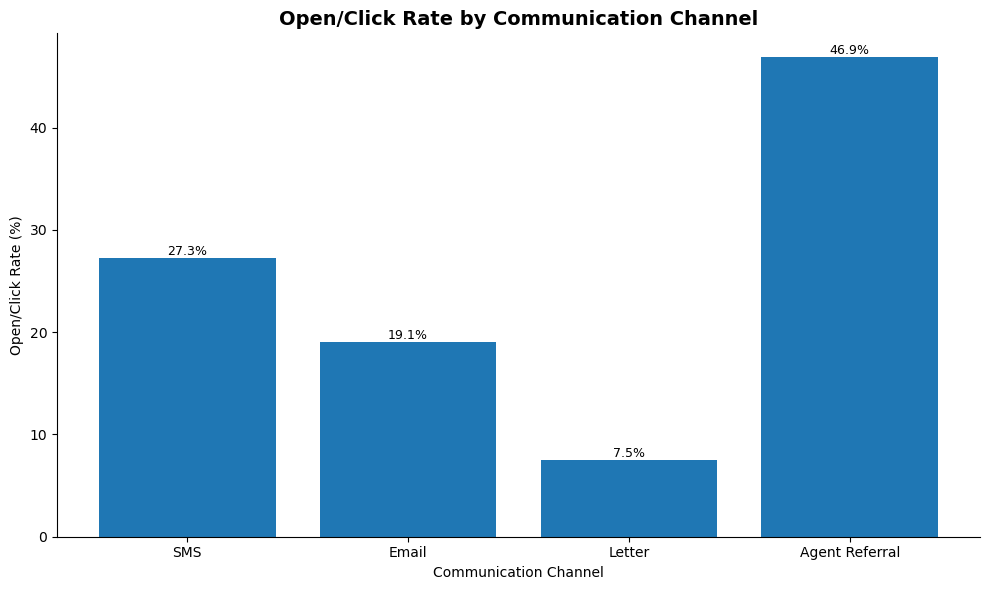

In [24]:
# 8. Plot open/click rate by channel
fig, ax = plt.subplots()

ax.bar(
    channel_engagement['channel'],
    channel_engagement['open_or_click_rate']
)

ax.set_title('Open/Click Rate by Communication Channel', fontsize=14, fontweight='bold')
ax.set_xlabel('Communication Channel')
ax.set_ylabel('Open/Click Rate (%)')

# 9. Add percentage labels
for index, value in enumerate(channel_engagement['open_or_click_rate']):
    ax.text(index, value, f'{value:.1f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(CHARTS_PATH, 'open_click_rate_by_channel.png'), dpi=300, bbox_inches='tight')
plt.show()

**Insight & Business Takeaway**

SMS is the dominant scalable digital channel by communication volume, followed by Email and Letter. Agent Referral shows stronger recorded engagement where present, but its role should be interpreted carefully because it is lower in scale and may represent assisted-to-digital handoff rather than a purely self-serve digital click.

For SMS and Email, open/click behaviour can be interpreted as direct digital engagement. For Letter and Agent Referral, the engagement metric should be read as recorded journey response or offline/assisted-to-digital entry, such as a QR code scan, portal visit, or agent-directed journey start.

**Indication:** Channel performance should be interpreted using both scale and channel context. Scalable improvement depends mainly on optimising high-volume channels such as SMS, while assisted or offline-to-digital channels can support specific customer journeys.

<h2 style="color: #F47B20; border-bottom: 2px solid #D9E2EC; padding-bottom: 8px; margin-top: 40px; font-weight: bold;">
Section 13: Overall Digital Collections Funnel
</h2>

**Visualise the End-to-End Customer Journey**

I am using the SQL-exported `overall_funnel.csv` file to visualise the full customer journey from account upload through to payment and repayment plan creation.

The funnel was calculated in BigQuery using distinct customer counts at each stage, which avoids inflating the numbers due to repeated reminders or repeated journey events.

In [25]:
# ============================================================
# Section 13: Overall Digital Collections Funnel
# ============================================================

# 1. Display the overall funnel table exported from SQL
overall_funnel

,stage_order,funnel_stage,customers,percent_of_uploaded_accounts
0,1,Account Uploaded,10000,100.00
1,2,Invite Sent,10000,100.00
2,3,Invite Delivered,9772,97.72
3,4,Link Opened,3695,36.95
4,5,Identity Verified,2458,24.58
5,6,Balance Viewed,2238,22.38
6,7,Payment Option Selected,1817,18.17
7,8,Payment Made,1206,12.06
8,9,Repayment Plan Created,743,7.43


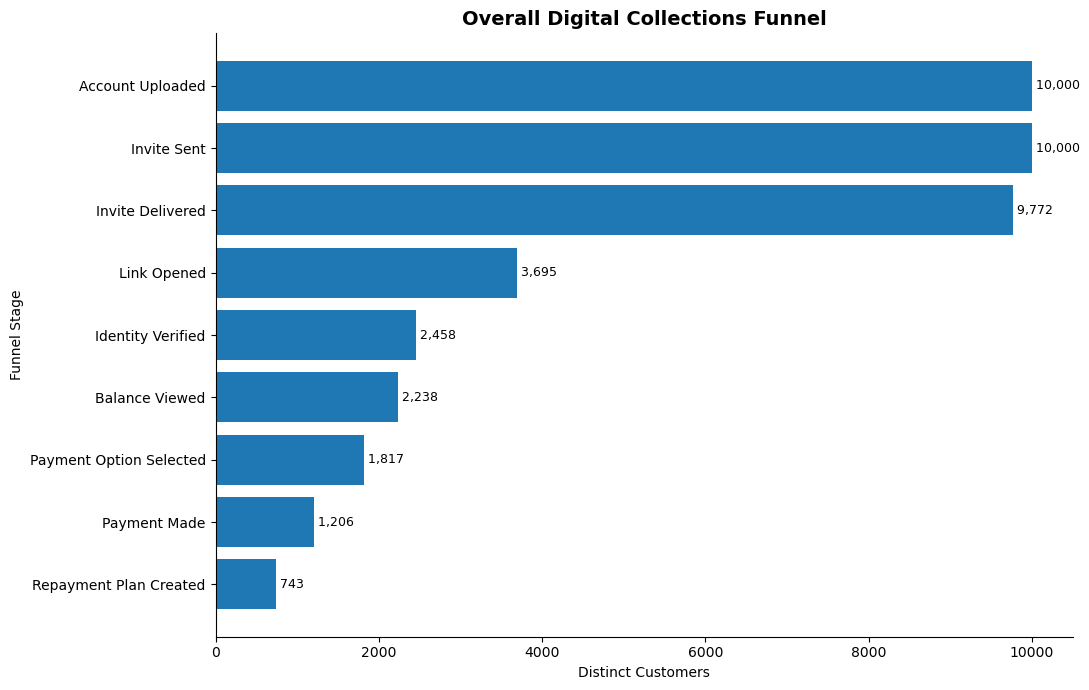

In [26]:
# 2. Plot overall digital collections funnel
fig, ax = plt.subplots(figsize=(11, 7))

ax.barh(
    overall_funnel['funnel_stage'],
    overall_funnel['customers']
)

ax.set_title('Overall Digital Collections Funnel', fontsize=14, fontweight='bold')
ax.set_xlabel('Distinct Customers')
ax.set_ylabel('Funnel Stage')

# 3. Reverse y-axis so the first funnel stage appears at the top
ax.invert_yaxis()

# 4. Add value labels
for index, value in enumerate(overall_funnel['customers']):
    ax.text(value, index, f' {value:,.0f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(CHARTS_PATH, 'overall_digital_collections_funnel.png'), dpi=300, bbox_inches='tight')
plt.show()

**Insight & Business Takeaway**

The overall funnel shows that the customer journey starts with 10,000 uploaded accounts and 9,772 delivered invites, but only 3,695 customers open the link. This highlights that the biggest early challenge is not upload volume or invite delivery, but customer engagement after delivery.

The funnel then narrows further through identity verification, balance view, and payment option selection. 

NOTE: The final stages, payment made and repayment plan created, should be interpreted as key journey outcomes rather than a strictly linear sequence, because some customers may make a one-off payment while others may create a repayment plan.

It is also important to note that this funnel uses the `payment_made` journey event. Later recovery analysis will use the payments table and successful payment status to calculate commercial repayment outcomes.

**Indication:** The biggest optimisation opportunity is improving the transition from delivered invite to link open, followed by reducing friction in identity verification and payment option selection.

<h2 style="color: #F47B20; border-bottom: 2px solid #D9E2EC; padding-bottom: 8px; margin-top: 40px; font-weight: bold;">
Section 14: Stage Drop-off Analysis
</h2>

**Identify the Largest Funnel Drop-offs**

I am analysing stage-to-stage conversion and drop-off rates to identify where the customer journey loses the most customers.

This is more useful than only looking at the final payment rate because it shows where the product or communication journey may need improvement.

In [27]:
# ============================================================
# Section 14: Stage Drop-off Analysis
# ============================================================

# 1. Display stage drop-off table exported from SQL
stage_drop_off

,stage_order,funnel_stage,customers,previous_stage_customers,stage_to_stage_conversion_percent,stage_drop_off_percent
0,2,Invite Sent,10000,10000,100.00,0.00
1,3,Invite Delivered,9772,10000,97.72,2.28
2,4,Link Opened,3695,9772,37.81,62.19
3,5,Identity Verified,2458,3695,66.52,33.48
4,6,Balance Viewed,2238,2458,91.05,8.95
5,7,Payment Option Selected,1817,2238,81.19,18.81
6,8,Payment Made,1206,1817,66.37,33.63
7,9,Repayment Plan Created,743,1206,61.61,38.39


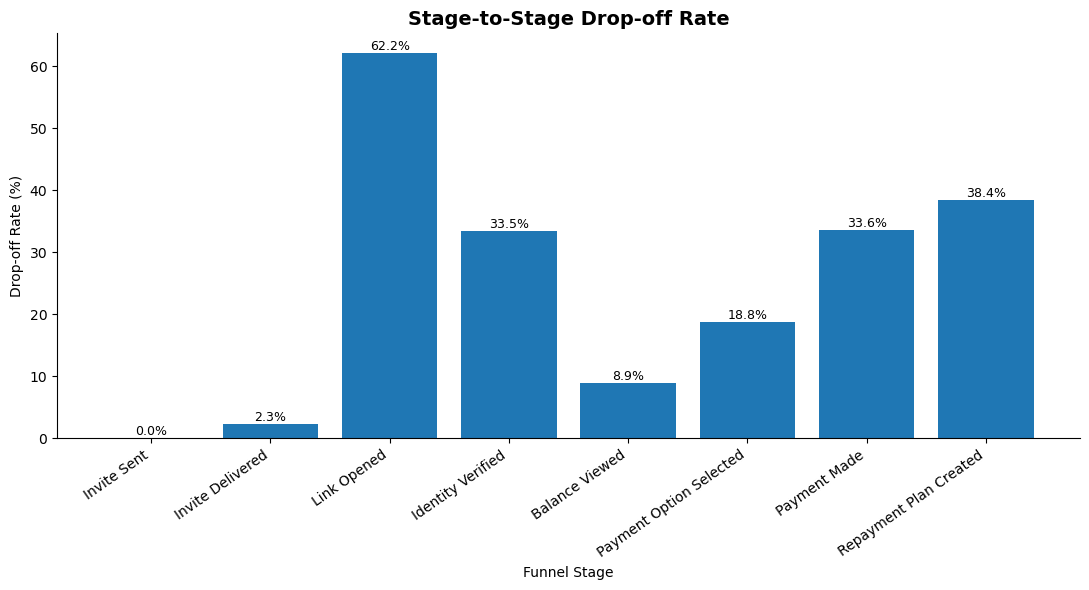

In [28]:
# 2. Plot stage drop-off percentage
fig, ax = plt.subplots(figsize=(11, 6))

ax.bar(
    stage_drop_off['funnel_stage'],
    stage_drop_off['stage_drop_off_percent']
)

ax.set_title('Stage-to-Stage Drop-off Rate', fontsize=14, fontweight='bold')
ax.set_xlabel('Funnel Stage')
ax.set_ylabel('Drop-off Rate (%)')

plt.xticks(rotation=35, ha='right')

# 3. Add percentage labels
for index, value in enumerate(stage_drop_off['stage_drop_off_percent']):
    ax.text(index, value, f'{value:.1f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(CHARTS_PATH, 'stage_drop_off_rate.png'), dpi=300, bbox_inches='tight')
plt.show()

**Insight & Business Takeaway**

The largest funnel drop-off occurs between **Invite Delivered** and **Link Opened**, showing that a large share of customers receive the communication but do not enter the digital journey.

A second important friction point appears between **Link Opened** and **Identity Verified**, suggesting that some customers who start the journey still fail to complete the verification step.

**Indication:** Journey optimisation should focus first on improving message engagement and then on simplifying or supporting identity verification.

<h2 style="color: #F47B20; border-bottom: 2px solid #D9E2EC; padding-bottom: 8px; margin-top: 40px; font-weight: bold;">
Section 15: Funnel Performance by Primary Channel
</h2>

**Compare Funnel Performance by Primary Communication Channel**

I am using the SQL-exported `funnel_by_channel.csv` file to compare how customers perform based on their first recorded communication or referral channel.

An important interpretation note is that downstream journey events such as link opened, identity verified, payment made, and repayment plan created are attributed back to the customer's primary channel. For SMS and Email, this can reflect direct digital engagement. For Letter and Agent Referral, this should be interpreted as offline-to-digital or assisted-to-digital journey entry, not as a native open/click inside the channel itself. This also explains why Agent Referral can appear as a meaningful communication event type in the raw channel distribution, but only a very small primary-channel group in the funnel attribution view. The channel funnel assigns each customer to their first recorded communication or referral channel.

**Letter with link_opened = customer first contacted by letter, then later entered digital journey**

**Agent Referral with link_opened = customer referred by agent, then later entered digital journey**

This analysis helps identify whether high-volume channels such as SMS are also driving stronger digital journey entry, payment conversion, and repayment plan setup.

In [29]:
# ============================================================
# Section 15: Funnel Performance by Channel
# ============================================================

# 1. Display funnel performance by primary communication channel
funnel_by_channel

,primary_channel,total_customers,invite_delivered_customers,link_opened_customers,identity_verified_customers,balance_viewed_customers,payment_option_selected_customers,payment_made_customers,repayment_plan_created_customers,link_open_rate,verification_after_open_rate,payment_conversion_rate,plan_setup_rate
0,SMS,5922,5814,2390,1604,1461,1181,797,494,41.11,67.11,13.71,8.50
1,Email,3015,2908,1022,684,625,507,330,206,35.14,66.93,11.35,7.08
2,Letter,1058,1045,279,166,148,125,76,40,26.70,59.50,7.27,3.83
3,Agent Referral,5,5,4,4,4,4,3,3,80.00,100.00,60.00,60.00


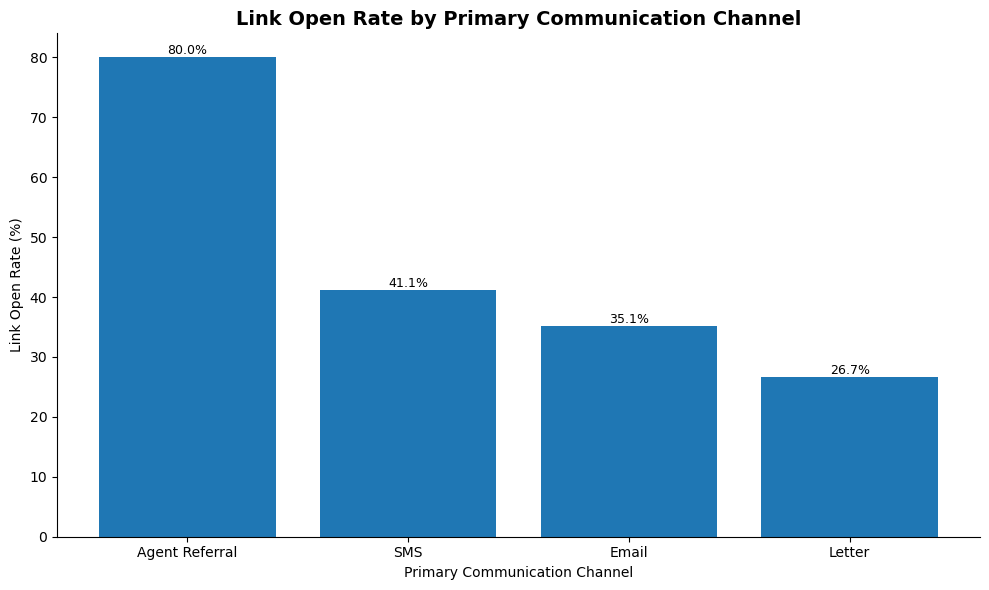

In [30]:
# 2. Plot link open rate by primary communication channel
channel_link_open = funnel_by_channel.sort_values('link_open_rate', ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(
    channel_link_open['primary_channel'],
    channel_link_open['link_open_rate']
)

ax.set_title('Link Open Rate by Primary Communication Channel', fontsize=14, fontweight='bold')
ax.set_xlabel('Primary Communication Channel')
ax.set_ylabel('Link Open Rate (%)')

# 3. Add percentage labels
for index, value in enumerate(channel_link_open['link_open_rate']):
    ax.text(index, value, f'{value:.1f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(CHARTS_PATH, 'link_open_rate_by_channel.png'), dpi=300, bbox_inches='tight')
plt.show()

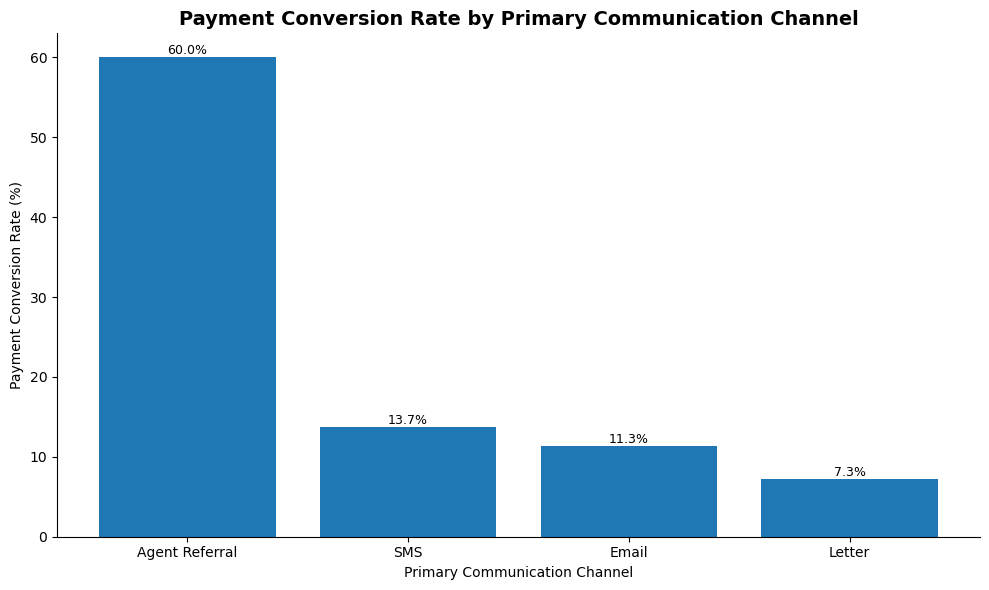

In [31]:
# 4. Plot payment conversion rate by primary communication channel
channel_payment = funnel_by_channel.sort_values('payment_conversion_rate', ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(
    channel_payment['primary_channel'],
    channel_payment['payment_conversion_rate']
)

ax.set_title('Payment Conversion Rate by Primary Communication Channel', fontsize=14, fontweight='bold')
ax.set_xlabel('Primary Communication Channel')
ax.set_ylabel('Payment Conversion Rate (%)')

# 5. Add percentage labels
for index, value in enumerate(channel_payment['payment_conversion_rate']):
    ax.text(index, value, f'{value:.1f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(CHARTS_PATH, 'payment_conversion_by_channel.png'), dpi=300, bbox_inches='tight')
plt.show()

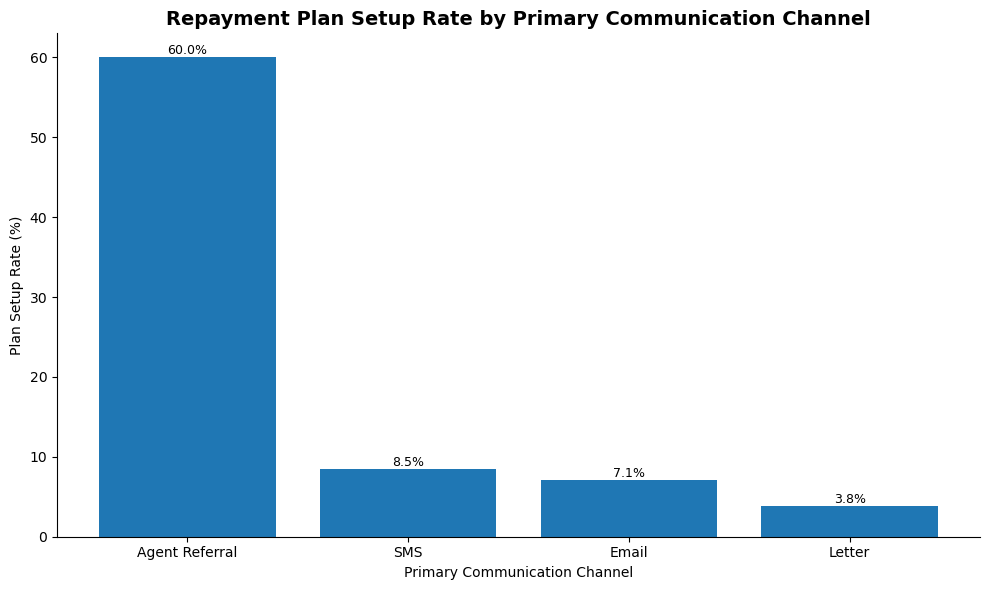

In [32]:
# 6. Plot repayment plan setup rate by primary communication channel
channel_plan = funnel_by_channel.sort_values('plan_setup_rate', ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(
    channel_plan['primary_channel'],
    channel_plan['plan_setup_rate']
)

ax.set_title('Repayment Plan Setup Rate by Primary Communication Channel', fontsize=14, fontweight='bold')
ax.set_xlabel('Primary Communication Channel')
ax.set_ylabel('Plan Setup Rate (%)')

# 7. Add percentage labels
for index, value in enumerate(channel_plan['plan_setup_rate']):
    ax.text(index, value, f'{value:.1f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(CHARTS_PATH, 'plan_setup_rate_by_channel.png'), dpi=300, bbox_inches='tight')
plt.show()

**Insight & Business Takeaway**

Channel performance should be interpreted through both **scale** and **quality**. SMS is the strongest scalable channel because it reaches the largest customer volume and performs well across link opening, payment conversion, and plan setup.

Agent Referral may show strong rates, but the underlying customer volume is very small, so it should not be treated as the main scalable growth lever.

**Indication:** DebtStream should prioritise SMS optimisation for scalable digital engagement, while using lower-volume assisted channels for specific customer segments where additional support is needed.

<h2 style="color: #F47B20; border-bottom: 2px solid #D9E2EC; padding-bottom: 8px; margin-top: 40px; font-weight: bold;">
Section 16: Funnel Performance by Balance Band
</h2>

**Compare Payment and Plan Behaviour by Balance Band**

I am using the SQL-exported `funnel_by_balance_band.csv` file to compare how customers behave across Low, Medium, High, and Very High debt balances.

This helps identify whether different balance bands should receive different digital journey strategies.

In [33]:
# ============================================================
# Section 16: Funnel Performance by Balance Band
# ============================================================

# 1. Display funnel performance by balance band
funnel_by_balance_band

,balance_band,total_customers,invite_delivered_customers,link_opened_customers,identity_verified_customers,payment_option_selected_customers,payment_made_customers,repayment_plan_created_customers,link_open_rate,payment_conversion_rate,plan_setup_rate
0,Low,3508,3427,1350,926,703,505,167,39.39,14.74,4.87
1,Medium,4065,3961,1477,978,739,476,409,37.29,12.02,10.33
2,High,1853,1826,690,444,313,192,149,37.79,10.51,8.16
3,Very High,574,558,178,110,62,33,18,31.90,5.91,3.23


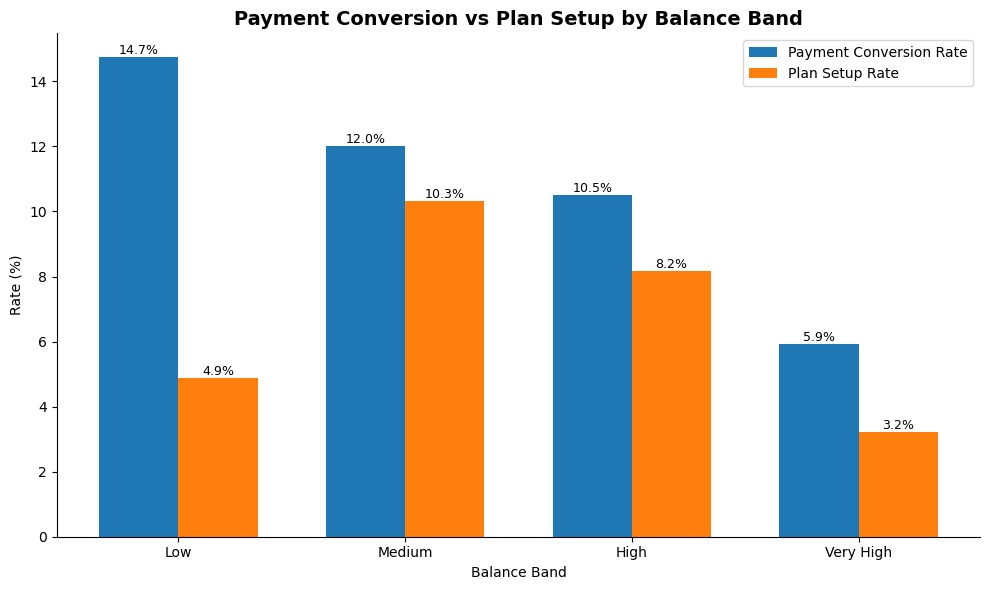

In [34]:
# 2. Prepare balance band order
balance_order = ['Low', 'Medium', 'High', 'Very High']

funnel_by_balance_band['balance_band'] = pd.Categorical(
    funnel_by_balance_band['balance_band'],
    categories=balance_order,
    ordered=True
)

funnel_by_balance_band = funnel_by_balance_band.sort_values('balance_band')

# 3. Create grouped bar chart for payment conversion and plan setup
x = np.arange(len(funnel_by_balance_band['balance_band']))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(
    x - width / 2,
    funnel_by_balance_band['payment_conversion_rate'],
    width,
    label='Payment Conversion Rate'
)

ax.bar(
    x + width / 2,
    funnel_by_balance_band['plan_setup_rate'],
    width,
    label='Plan Setup Rate'
)

ax.set_title('Payment Conversion vs Plan Setup by Balance Band', fontsize=14, fontweight='bold')
ax.set_xlabel('Balance Band')
ax.set_ylabel('Rate (%)')
ax.set_xticks(x)
ax.set_xticklabels(funnel_by_balance_band['balance_band'].astype(str))
ax.legend()

# 4. Add labels for both bars
for index, value in enumerate(funnel_by_balance_band['payment_conversion_rate']):
    ax.text(index - width / 2, value, f'{value:.1f}%', ha='center', va='bottom', fontsize=9)

for index, value in enumerate(funnel_by_balance_band['plan_setup_rate']):
    ax.text(index + width / 2, value, f'{value:.1f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(CHARTS_PATH, 'payment_vs_plan_setup_by_balance_band.png'), dpi=300, bbox_inches='tight')
plt.show()

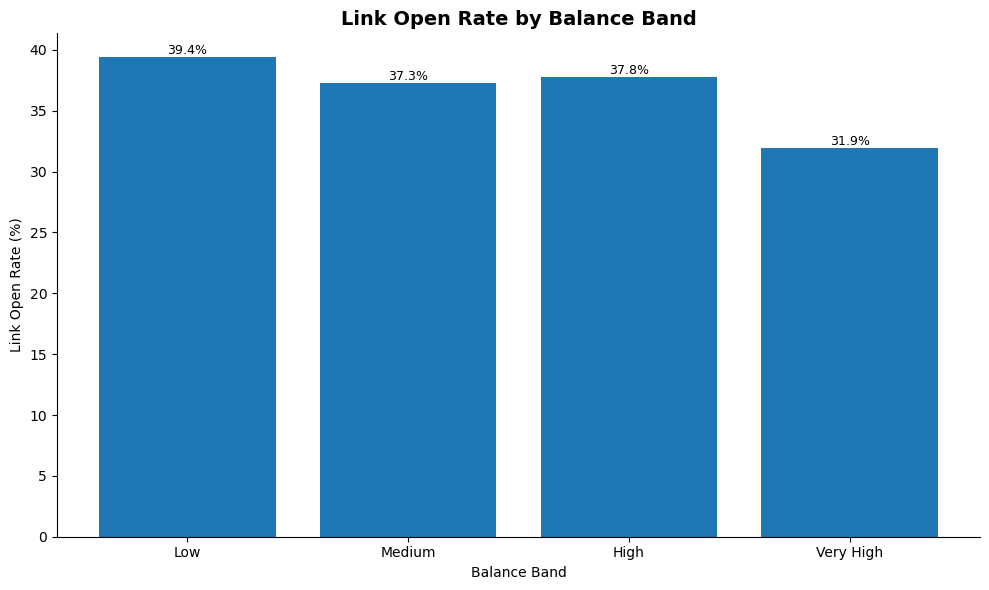

In [35]:
# 5. Plot link open rate by balance band
fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(
    funnel_by_balance_band['balance_band'].astype(str),
    funnel_by_balance_band['link_open_rate']
)

ax.set_title('Link Open Rate by Balance Band', fontsize=14, fontweight='bold')
ax.set_xlabel('Balance Band')
ax.set_ylabel('Link Open Rate (%)')

# 6. Add percentage labels
for index, value in enumerate(funnel_by_balance_band['link_open_rate']):
    ax.text(index, value, f'{value:.1f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(CHARTS_PATH, 'link_open_rate_by_balance_band.png'), dpi=300, bbox_inches='tight')
plt.show()

**Insight & Business Takeaway**

Balance band analysis shows that customer behaviour differs meaningfully by debt balance.

Low-balance customers are more likely to complete payment journeys, which makes them suitable for direct payment-led nudges. Medium-balance customers show stronger repayment plan setup behaviour, suggesting that they may respond better to flexible repayment options.

Very High-balance customers show weaker journey outcomes, which indicates that they may require more support-led or affordability-led journeys rather than standard self-service nudges alone.

**Indication:** DebtStream should avoid using a single journey strategy for all balances. Balance band should influence message tone, payment options, and support prompts.

<h2 style="color: #F47B20; border-bottom: 2px solid #D9E2EC; padding-bottom: 8px; margin-top: 40px; font-weight: bold;">
Section 17: Monthly Funnel Trend
</h2>

**Analyse Monthly Customer Upload and Funnel Performance**

I am using the SQL-exported `monthly_funnel_trend.csv` file to understand how customer volume, engagement, payment conversion, and repayment plan setup changed over time.

This helps identify whether performance was stable throughout the project period or varied across months.

In [36]:
# ============================================================
# Section 17: Monthly Funnel Trend
# ============================================================

# 1. Convert upload_month to datetime
monthly_funnel_trend['upload_month'] = pd.to_datetime(monthly_funnel_trend['upload_month'])

# 2. Display monthly funnel trend table
monthly_funnel_trend

,upload_month,uploaded_customers,invite_delivered_customers,link_opened_customers,identity_verified_customers,payment_made_customers,repayment_plan_created_customers,link_open_rate,payment_conversion_rate,plan_setup_rate
0,2022-06-01,716,701,277,178,86,49,39.51,12.27,6.99
1,2022-07-01,767,742,262,176,94,50,35.31,12.67,6.74
2,2022-08-01,760,732,280,181,90,68,38.25,12.30,9.29
3,2022-09-01,932,914,340,230,107,61,37.20,11.71,6.67
4,2022-10-01,928,912,341,224,105,65,37.39,11.51,7.13
5,2022-11-01,919,903,352,232,108,65,38.98,11.96,7.20
6,2022-12-01,577,566,221,154,80,37,39.05,14.13,6.54
7,2023-01-01,1008,987,370,246,124,73,37.49,12.56,7.40
8,2023-02-01,912,891,344,226,95,66,38.61,10.66,7.41
9,2023-03-01,954,932,352,220,95,73,37.77,10.19,7.83


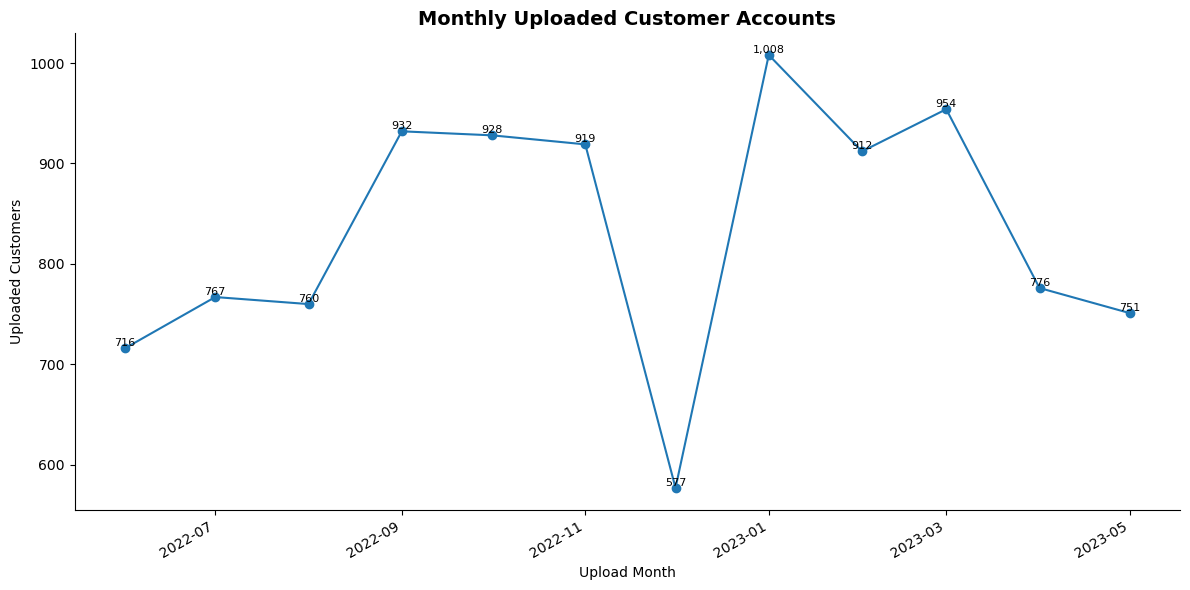

In [37]:
# 3. Plot monthly uploaded customers
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(
    monthly_funnel_trend['upload_month'],
    monthly_funnel_trend['uploaded_customers'],
    marker='o'
)

ax.set_title('Monthly Uploaded Customer Accounts', fontsize=14, fontweight='bold')
ax.set_xlabel('Upload Month')
ax.set_ylabel('Uploaded Customers')

# 4. Add value labels
for x_value, y_value in zip(monthly_funnel_trend['upload_month'], monthly_funnel_trend['uploaded_customers']):
    ax.text(x_value, y_value, f'{y_value:,.0f}', ha='center', va='bottom', fontsize=8)

plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(CHARTS_PATH, 'monthly_uploaded_customers.png'), dpi=300, bbox_inches='tight')
plt.show()

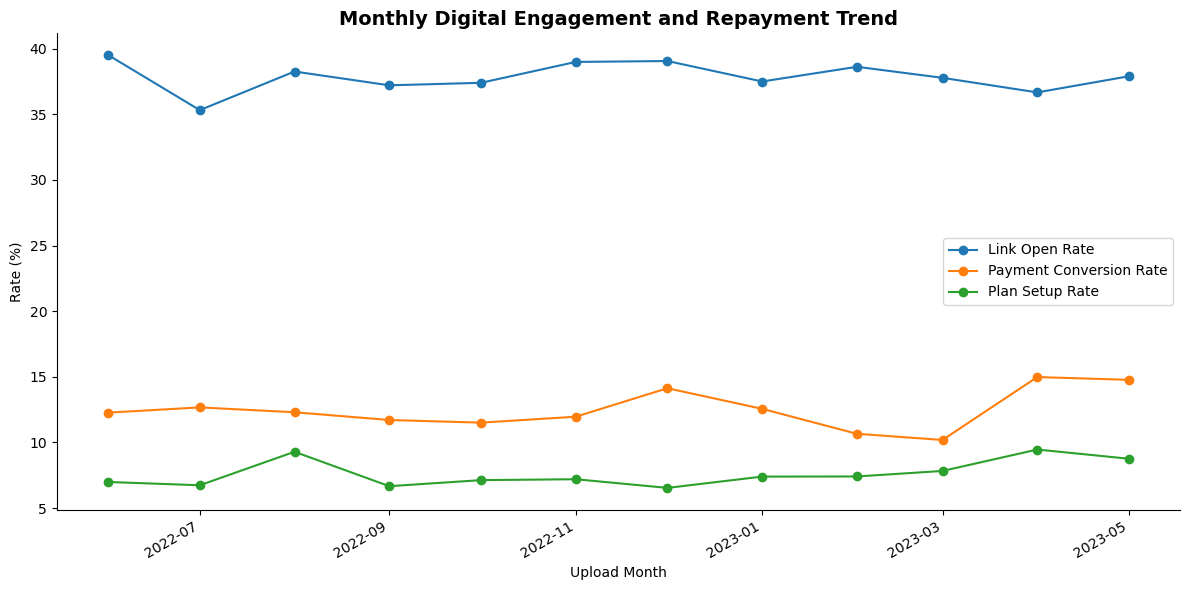

In [39]:
# 5. Plot monthly link open, payment conversion, and plan setup trends
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(
    monthly_funnel_trend['upload_month'],
    monthly_funnel_trend['link_open_rate'],
    marker='o',
    label='Link Open Rate'
)

ax.plot(
    monthly_funnel_trend['upload_month'],
    monthly_funnel_trend['payment_conversion_rate'],
    marker='o',
    label='Payment Conversion Rate'
)

ax.plot(
    monthly_funnel_trend['upload_month'],
    monthly_funnel_trend['plan_setup_rate'],
    marker='o',
    label='Plan Setup Rate'
)

ax.set_title('Monthly Digital Engagement and Repayment Trend', fontsize=14, fontweight='bold')
ax.set_xlabel('Upload Month')
ax.set_ylabel('Rate (%)')
ax.legend()

plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(CHARTS_PATH, 'monthly_funnel_performance_trend.png'), dpi=300, bbox_inches='tight')
plt.show()

**Insight & Business Takeaway**

The monthly trend shows that both customer upload volume and funnel performance vary across the project period. This is realistic for a B2B collections platform because client portfolios are often uploaded in batches, and monthly outcomes can shift depending on client mix, portfolio type, debt age, and communication strategy.

The rate-based view shows that link open rate, payment conversion rate, and repayment plan setup rate do not move identically every month. This suggests that engagement, payment behaviour, and plan creation should be tracked separately rather than treated as one single funnel metric.

**Indication:** Monthly tracking should be included in the Power BI report so stakeholders can monitor volume, engagement, payment conversion, and repayment plan setup over time.

<h2 style="color: #F47B20; border-bottom: 2px solid #D9E2EC; padding-bottom: 8px; margin-top: 40px; font-weight: bold;">
Section 18: Chart Exports
</h2>

In [40]:
# ============================================================
# Section 18: Confirm Chart Exports
# ============================================================

# 1. List all chart files exported from this notebook
exported_charts = sorted([
    file for file in os.listdir(CHARTS_PATH)
    if file.endswith('.png')
])

# 2. Display exported chart names
exported_charts

['communication_events_by_channel.png',
 'customer_distribution_by_balance_band.png',
 'customer_distribution_by_client_type.png',
 'customer_distribution_by_debt_age_band.png',
 'customer_distribution_by_portfolio_type.png',
 'link_open_rate_by_balance_band.png',
 'link_open_rate_by_channel.png',
 'monthly_funnel_performance_trend.png',
 'monthly_uploaded_customers.png',
 'open_click_rate_by_channel.png',
 'overall_digital_collections_funnel.png',
 'payment_conversion_by_channel.png',
 'payment_vs_plan_setup_by_balance_band.png',
 'plan_setup_rate_by_channel.png',
 'stage_drop_off_rate.png']

<h2 style="color: #F47B20; border-bottom: 2px solid #D9E2EC; padding-bottom: 8px; margin-top: 40px; font-weight: bold;">
Section 19: Final Notebook Summary
</h2>

**Summarise Key Findings from Data Validation and EDA**

This final section summarises the main findings from this notebook before moving into the SMS A/B testing notebook.

## Final Findings

**1. The dataset loaded correctly and matched SQL validation.**  
All six raw tables loaded successfully in Python and matched the row counts validated earlier in BigQuery. This confirms that the Python environment is aligned with the SQL phase.

**2. Missing values are mostly explainable in business context.**  
The largest missing value percentage appears in `journey_events.device_type`, but this is expected because many journey events are system-driven rather than device-based customer actions.

**3. The biggest funnel challenge is customer engagement after invite delivery.**  
The funnel shows a major drop-off between invite delivery and link open, which means the issue is not simply message delivery but getting customers to start the digital journey.

**4. Identity verification is a second important friction point.**  
A meaningful share of customers who open the journey do not complete identity verification, suggesting a potential product or trust barrier.

**5. Channel performance should be interpreted using both volume and quality.**  
SMS is the strongest scalable digital channel, while low-volume assisted channels may show high rates but limited scalability.

**6. Balance band behaviour differs meaningfully.**  
Low-balance customers are more likely to complete payment journeys, while Medium-balance customers show stronger repayment plan setup behaviour.

**7. Monthly tracking is important for stakeholder reporting.**  
Customer upload volume and funnel performance vary by month, so the final Power BI dashboard should allow stakeholders to track these changes over time.

## Next Steps

The next notebook will focus on the SMS A/B test.

The objective will be to evaluate whether supportive repayment messaging improved link opens, payment behaviour, repayment plan setup, and recovery outcomes compared with a direct payment reminder.